# NeuralProphet 时序预测——项目数量

使用 NeuralProphet 对月度累计项目数进行预测，与同目录的 Prophet 和 Chronos-2 结果横向对比。

数据：`data/project.csv`（47行，月度，2022-03 ~ 2026-01）

训练集：前 80%（37行）；测试集：后 20%（10行）；预测步长：10个月

In [ ]:
import os

# 不使用GPU
os.environ['CUDA_VISIBLE_DEVICES'] = ''
# PyTorch 2.6版本的兼容问题
os.environ['TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD'] = '1'

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import warnings
warnings.filterwarnings('ignore')
from neuralprophet import NeuralProphet, set_log_level
set_log_level('ERROR')

plt.rcParams['font.sans-serif'] = ['WenQuanYi Zen Hei', 'WenQuanYi Micro Hei']
plt.rcParams['axes.unicode_minus'] = False

df = pd.read_csv('data/project.csv')
df = df.rename(columns={'timestamp': 'ds', 'target': 'y'})[['ds', 'y']]
df['ds'] = pd.to_datetime(df['ds'])
print(f'数据行数: {len(df)}，时间范围: {df["ds"].min().date()} ~ {df["ds"].max().date()}')
df.tail(10)

数据行数: 47，时间范围: 2022-03-01 ~ 2026-01-01


,ds,y
37,2025-04-01,49
38,2025-05-01,51
39,2025-06-01,55
40,2025-07-01,56
41,2025-08-01,61
42,2025-09-01,62
43,2025-10-01,62
44,2025-11-01,64
45,2025-12-01,65
46,2026-01-01,66


训练集: 37 行  (2022-03-01 ~ 2025-03-01)
测试集: 10 行  (2025-04-01 ~ 2026-01-01)
预测步长: 10 个月


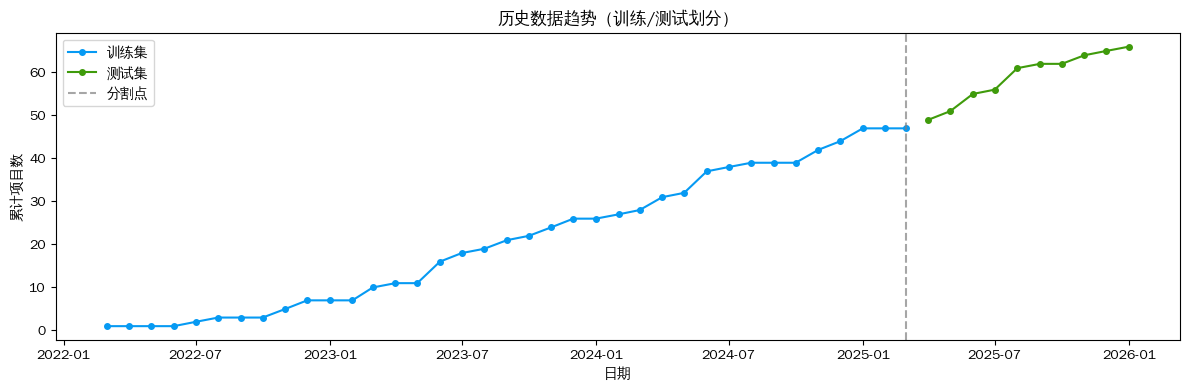

In [23]:
# 按 80/20 划分训练集和测试集
TRAIN_RATIO = 0.8
split_idx = int(len(df) * TRAIN_RATIO)
train_df = df.iloc[:split_idx].copy()
test_df  = df.iloc[split_idx:].copy()
PRED_LEN = len(test_df)

print(f'训练集: {len(train_df)} 行  ({train_df["ds"].min().date()} ~ {train_df["ds"].max().date()})')
print(f'测试集: {len(test_df)} 行  ({test_df["ds"].min().date()} ~ {test_df["ds"].max().date()})')
print(f'预测步长: {PRED_LEN} 个月')

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(train_df['ds'], train_df['y'], marker='o', markersize=4, color='xkcd:azure', label='训练集')
ax.plot(test_df['ds'],  test_df['y'],  marker='o', markersize=4, color='xkcd:grass green', label='测试集')
ax.axvline(x=train_df['ds'].iloc[-1], color='gray', linestyle='--', alpha=0.7, label='分割点')
ax.set_title('历史数据趋势（训练/测试划分）')
ax.set_xlabel('日期')
ax.set_ylabel('累计项目数')
ax.legend()
plt.tight_layout()
plt.show()

In [24]:
# NeuralProphet 月度数据配置
# n_forecasts=PRED_LEN: 一次输出全部预测步长
# n_lags=0: 关闭 AR-Net，保留季节性分解，与 Prophet 对齐
# quantiles: 输出 10%/90% 置信区间
m = NeuralProphet(
    n_forecasts=PRED_LEN,
    n_lags=0,
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False,
    seasonality_mode='additive',
    quantiles=[0.1, 0.9],
    trainer_config={
        'accelerator': 'cpu',
        'devices': 1,
    },
)
metrics = m.fit(train_df, freq='MS')
print('模型训练完成')

Training: |          | 0/? [00:00<?, ?it/s]

Finding best initial lr: 100%|██████████| 203/203 [00:01<00:00, 123.91it/s]


Training: |          | 0/? [00:17<?, ?it/s, v_num=6, train_loss=0.000298, reg_loss=0.000, MAE=0.507, RMSE=0.627, Loss=0.000326, RegLoss=0.000]
模型训练完成


In [25]:
# 生成未来预测（make_future_dataframe 自动延伸 n_forecasts 步）
future = m.make_future_dataframe(train_df, periods=PRED_LEN)
forecast = m.predict(future)

# 提取测试期预测结果
forecast_test = forecast.tail(PRED_LEN)[['ds', 'yhat1', 'yhat1 10.0%', 'yhat1 90.0%']].reset_index(drop=True)
forecast_test.columns = ['ds', 'yhat', 'yhat_lower', 'yhat_upper']
print(f'预测期: {forecast_test["ds"].iloc[0].date()} ~ {forecast_test["ds"].iloc[-1].date()}')
forecast_test

Predicting DataLoader 0: 100%|██████████| 1/1 [00:00<00:00, 187.80it/s]
预测期: 2025-04-01 ~ 2026-01-01


,ds,yhat,yhat_lower,yhat_upper
0,2025-04-01,49.918129,49.414906,50.445183
1,2025-05-01,50.613052,49.734245,51.594360
2,2025-06-01,54.741825,53.248962,55.827560
3,2025-07-01,56.239037,54.984749,57.148342
4,2025-08-01,57.208935,55.963608,57.916832
5,2025-09-01,57.746605,56.693420,58.058327
6,2025-10-01,58.175434,56.855579,58.806114
7,2025-11-01,60.767967,59.832539,61.111622
8,2025-12-01,62.975014,61.858685,63.556469
9,2026-01-01,64.450653,62.965450,65.790115


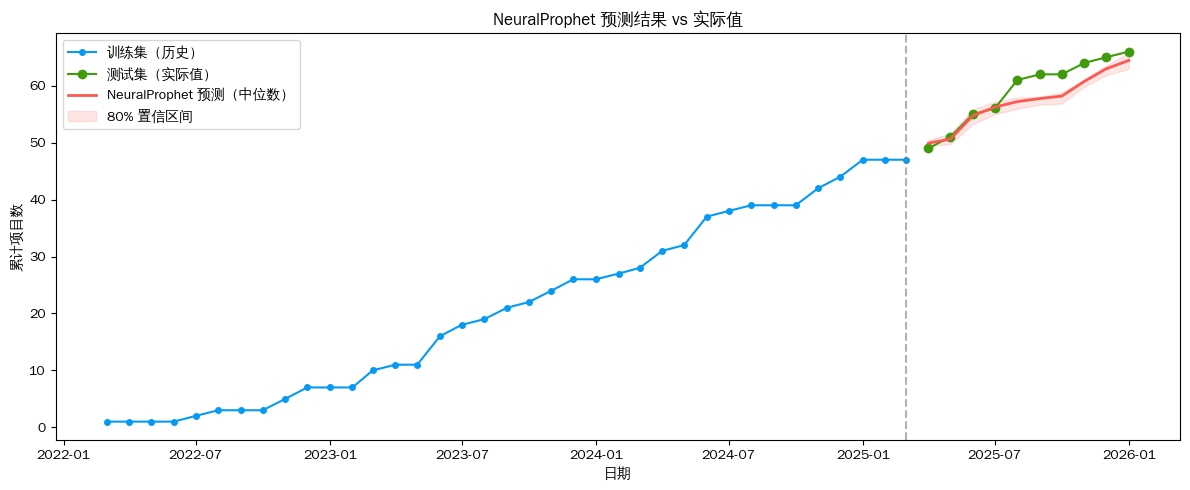

In [26]:
# 绘制预测结果 vs 实际值
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(train_df['ds'], train_df['y'],
        color='xkcd:azure', marker='o', markersize=4, label='训练集（历史）')
ax.plot(test_df['ds'],  test_df['y'],
        color='xkcd:grass green', marker='o', markersize=6, label='测试集（实际值）')
ax.plot(forecast_test['ds'], forecast_test['yhat'],
        color='xkcd:coral', linewidth=2, label='NeuralProphet 预测（中位数）')
ax.fill_between(forecast_test['ds'],
                forecast_test['yhat_lower'], forecast_test['yhat_upper'],
                color='xkcd:coral', alpha=0.15, label='80% 置信区间')
ax.axvline(x=train_df['ds'].iloc[-1], color='gray', linestyle='--', alpha=0.6)
ax.set_title('NeuralProphet 预测结果 vs 实际值')
ax.set_xlabel('日期')
ax.set_ylabel('累计项目数')
ax.legend()
plt.tight_layout()
plt.show()

In [27]:
# 误差指标：MAE、RMSE、MAPE
y_true = test_df['y'].values
y_pred = forecast_test['yhat'].values

mae  = np.mean(np.abs(y_true - y_pred))
rmse = np.sqrt(np.mean((y_true - y_pred) ** 2))
mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100

print('─' * 35)
print(f'  MAE  (平均绝对误差):      {mae:.3f}')
print(f'  RMSE (均方根误差):        {rmse:.3f}')
print(f'  MAPE (平均绝对百分误差):  {mape:.2f}%')
print('─' * 35)

───────────────────────────────────
  MAE  (平均绝对误差):      2.048
  RMSE (均方根误差):        2.553
  MAPE (平均绝对百分误差):  3.33%
───────────────────────────────────
